# NEU Surface Defect Database — Exploratory Analysis

Six defect classes from hot-rolled steel strip surfaces, 300 images each,
200×200 grayscale. This notebook looks at class balance, what each defect
actually looks like, pixel-intensity characteristics per class, and the
augmentations used during training.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

RAW = Path("../data/raw")
CLASSES = ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]

## 1. Class distribution

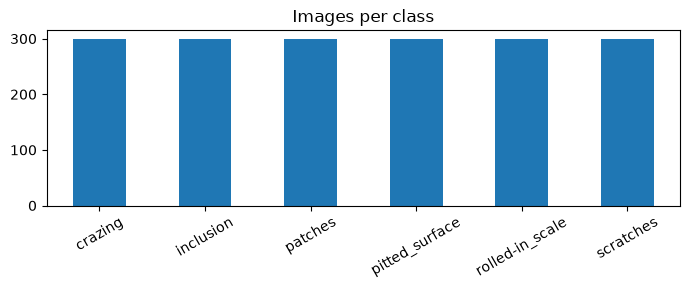

Total: 1800 images — perfectly balanced dataset


In [2]:
counts = {c: len(list((RAW / c).glob("*.jpg"))) for c in CLASSES}
pd.Series(counts).plot.bar(title="Images per class", rot=30, figsize=(7, 3))
plt.tight_layout()
plt.show()
print(f"Total: {sum(counts.values())} images — perfectly balanced dataset")

## 2. What does each defect look like?

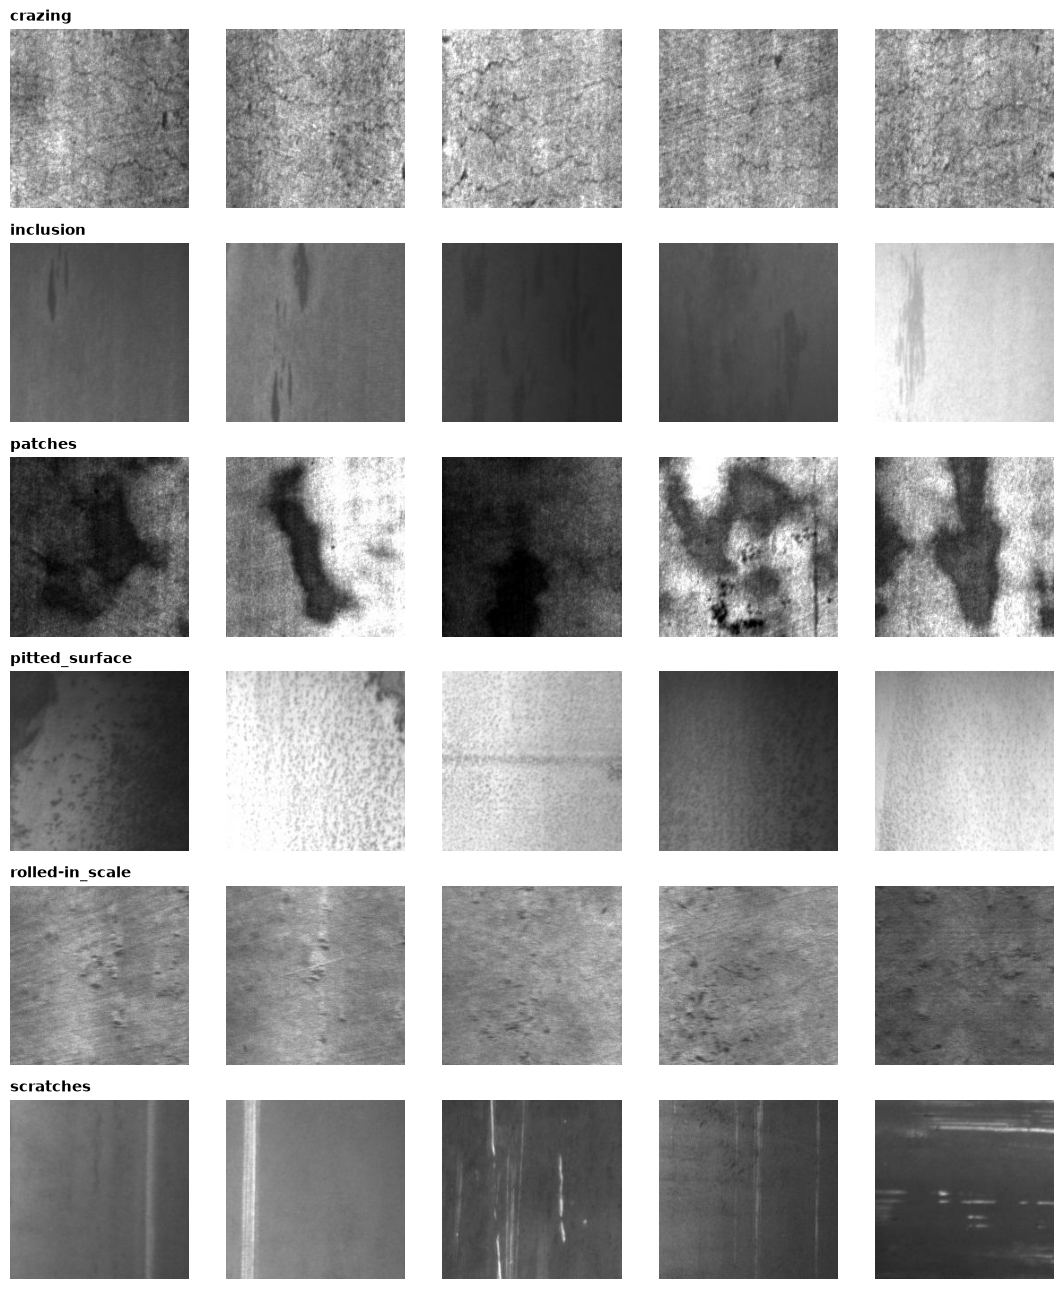

In [3]:
fig, axes = plt.subplots(6, 5, figsize=(11, 13))
rng = np.random.default_rng(42)
for row, cls in enumerate(CLASSES):
    files = sorted((RAW / cls).glob("*.jpg"))
    for col, f in enumerate(rng.choice(files, 5, replace=False)):
        ax = axes[row, col]
        ax.imshow(Image.open(f), cmap="gray")
        ax.axis("off")
        if col == 0:
            ax.set_title(cls, loc="left", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

**Observations**

- **crazing** — dense networks of fine cracks, fairly uniform texture
- **inclusion** — dark elongated blobs on smoother background
- **patches** — large irregular bright/dark regions
- **pitted_surface** — clusters of small cavities, locally rough
- **rolled-in_scale** — scattered dark spots pressed into the surface
- **scratches** — thin bright lines, often near-vertical or diagonal

The classes are visually well separated, which explains why transfer
learning reaches very high accuracy on this dataset.

## 3. Image properties & pixel intensity by class

In [4]:
rows = []
for cls in CLASSES:
    for f in sorted((RAW / cls).glob("*.jpg")):
        arr = np.asarray(Image.open(f).convert("L"), dtype=np.float32)
        rows.append({"cls": cls, "w": arr.shape[1], "h": arr.shape[0],
                     "mean": arr.mean(), "std": arr.std()})
stats = pd.DataFrame(rows)
print("Image sizes:", stats[["w", "h"]].drop_duplicates().values.tolist())
stats.groupby("cls")[["mean", "std"]].mean().round(1)

Image sizes: [[200, 200]]


,mean,std
cls,,
crazing,141.100006,28.799999
inclusion,106.400002,13.000000
patches,132.399994,54.000000
pitted_surface,176.600006,26.600000
rolled-in_scale,117.900002,15.700000
scratches,95.099998,21.700001


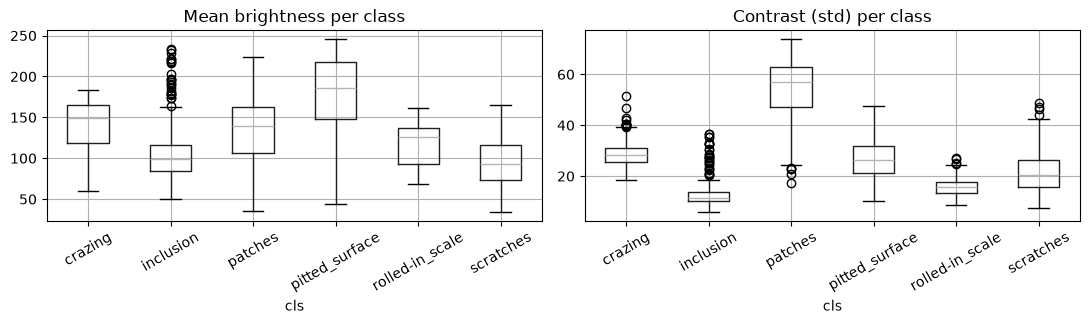

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
stats.boxplot(column="mean", by="cls", rot=30, ax=axes[0])
axes[0].set_title("Mean brightness per class")
stats.boxplot(column="std", by="cls", rot=30, ax=axes[1])
axes[1].set_title("Contrast (std) per class")
plt.suptitle("")
plt.tight_layout()
plt.show()

Brightness varies a lot **within** classes (lighting differences between
strips), so the model cannot rely on global brightness — good. Contrast is
somewhat class-correlated (crazing/pitted have high texture, patches lower),
which is a legitimate signal. Brightness/contrast jitter in augmentation
prevents over-reliance on absolute intensity.

## 4. Training augmentation preview

C:\Users\Cakarokko\AppData\Local\Temp\ipykernel_27636\8966679.py:11: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  aug = aug * np.array([0.229, 0.224, 0.225])[:, None, None] + np.array([0.485, 0.456, 0.406])[:, None, None]


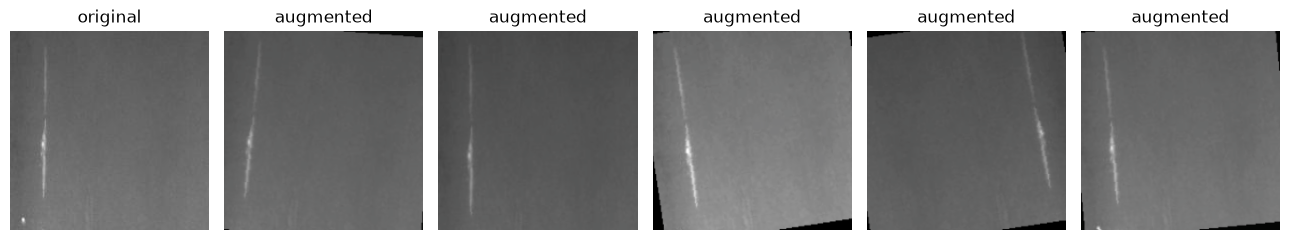

In [6]:
import sys
sys.path.append("../model")
from model_loader import train_transform

tf = train_transform()
src = Image.open(sorted((RAW / "scratches").glob("*.jpg"))[0])
fig, axes = plt.subplots(1, 6, figsize=(13, 2.6))
axes[0].imshow(src, cmap="gray"); axes[0].set_title("original"); axes[0].axis("off")
for ax in axes[1:]:
    aug = tf(src)
    aug = aug * np.array([0.229, 0.224, 0.225])[:, None, None] + np.array([0.485, 0.456, 0.406])[:, None, None]
    ax.imshow(aug.permute(1, 2, 0).clip(0, 1)); ax.set_title("augmented"); ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Takeaways for modeling

1. **Balanced classes** → plain accuracy is a meaningful metric, no need for
   class weighting.
2. **Small, visually distinct dataset** → ImageNet-pretrained ResNet18 with a
   new 6-class head is more than sufficient (confirmed: 100% test accuracy).
3. **Grayscale 200×200 inputs** → replicated to 3 channels and resized to
   224×224 to match the pretrained backbone.
4. **Studio-quality images** → real production-line images would be noisier;
   augmentation narrows but does not close this domain gap.
5. Defects like inclusion/scratches are localized → bounding-box detection
   (YOLO, Phase 2) adds value beyond whole-image classification.